In [12]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from shared_logic import drop_customer_id, load_customer_data, log1p_transform, median_impute, save_dataframe

# Notebook 2: Real-World Customer Segmentation
## 1. Data Acquisition and Initial Exploration
In this phase, we move beyond synthetic blobs and analyze a high-dimensional dataset of credit-card holders.

**Objectives:**
- Handle missing values and outliers in real-world financial data.
- Apply PCA to reduce 17 features into principal components for geometric analysis.
- Emphasize the math behind each step: transformation, scaling, covariance structure, and projection.

**Mathematical Roadmap:**
Given a data matrix $X \in \mathbb{R}^{n \times p}$, we construct a transformed matrix $\tilde{X}$, standardize it into $Z$, compute the covariance matrix $\Sigma = \frac{1}{n-1} Z^T Z$, and project data onto principal axes.

$$Z = \frac{\tilde{X} - \mu}{\sigma}, \qquad \Sigma v_i = \lambda_i v_i, \qquad Y = ZV_k$$


In [13]:

data_candidates = [
    Path('CC GENERAL.csv'),
    Path('notebooks/CC GENERAL.csv'),
    Path('../data/CC GENERAL.csv')
 ]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Could not locate 'CC GENERAL.csv'. Tried: {[str(path) for path in data_candidates]}"
    )

df_real = load_customer_data(str(data_path))

print(f"Dataset Shape: {df_real.shape}")
df_real.info()

Dataset Shape: (8950, 18)
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int6

In [5]:
display(df_real.describe())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
df_real_data = drop_customer_id(df_real, id_col='CUST_ID')
df_real_data

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [7]:
df_real_data = median_impute(df_real_data, columns=['MINIMUM_PAYMENTS', 'CREDIT_LIMIT'])

print("\nMissing Values After Imputation:")
print(df_real_data.isnull().sum())


Missing Values After Imputation:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [8]:
df_log = log1p_transform(df_real_data)

print("\nLog-Transformed Data Preview:")
display(df_log.head())

skew_before = df_real_data.skew(numeric_only=True)
skew_after = df_log.skew(numeric_only=True)

skew_comparison = pd.DataFrame({
    'Skew Before': skew_before,
    'Skew After': skew_after,
    'Absolute Reduction': skew_before.abs() - skew_after.abs()
}).sort_values('Absolute Reduction', ascending=False)

print("\nTop features with largest skewness reduction:")
display(skew_comparison.head(10))


Log-Transformed Data Preview:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949
3,7.419183,0.492477,7.313220,7.313220,0.000000,5.331694,0.080042,0.080042,0.000000,0.080042,0.693147,0.693147,8.922792,0.000000,5.747301,0.000000,2.564949
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949



Top features with largest skewness reduction:


,Skew Before,Skew After,Absolute Reduction
MINIMUM_PAYMENTS,13.852446,0.269703,13.582743
ONEOFF_PURCHASES,10.045083,0.185854,9.859229
PURCHASES,8.144269,-0.764492,7.379777
INSTALLMENTS_PURCHASES,7.299120,-0.024981,7.274139
CASH_ADVANCE,5.166609,0.262594,4.904015
CASH_ADVANCE_TRX,5.721298,0.940131,4.781167
PURCHASES_TRX,4.630655,0.032697,4.597958
PAYMENTS,5.907620,-1.778312,4.129308
BALANCE,2.393386,-0.861021,1.532365
CREDIT_LIMIT,1.522636,-0.101408,1.421228


### 2. Mathematical Reasoning for Preprocessing
1. **Median Imputation**: for each feature $f$, missing entries are replaced by
$$x_{i,f} \leftarrow \operatorname{median}(x_{:,f})$$
This is robust to extreme values compared with the mean.

2. **Log Transformation**: many monetary variables are right-skewed. We use
$$g(x) = \ln(1 + x)$$
to compress large values and reduce skewness while preserving order.

3. **Why this matters for distance-based models**: K-Means and PCA rely on Euclidean geometry. Reducing skew and extreme scale imbalance makes distances more stable and improves the conditioning of covariance estimates.

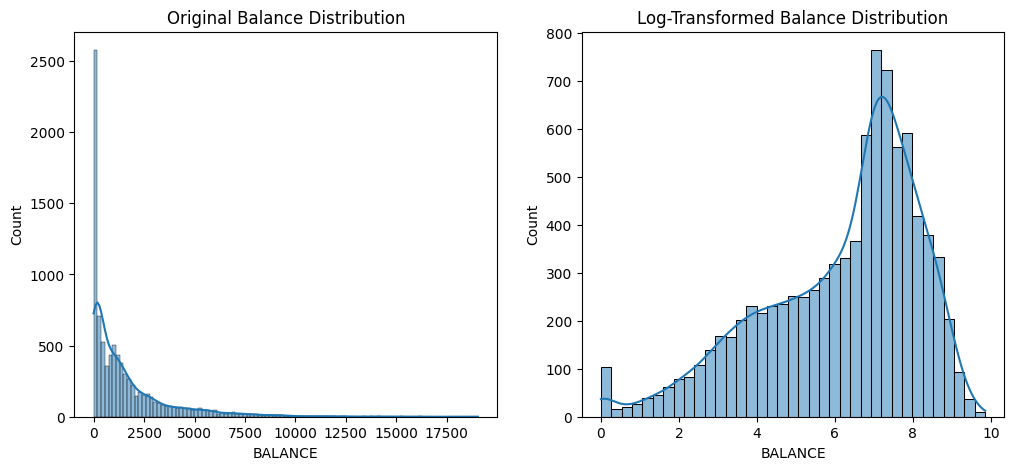

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_real_data['BALANCE'], kde=True)
plt.title('Original Balance Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_log['BALANCE'], kde=True)
plt.title('Log-Transformed Balance Distribution')

plt.show()

### 3. Feature Scaling for PCA
Principal Component Analysis (PCA) is a variance-maximizing exercise. It projects the original data onto directions which maximize the variance. To ensure that all features contribute equally, we must apply **StandardScaler**, centering the mean at 0 and scaling to unit variance.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

In [14]:
scaling_check = pd.DataFrame({
    'Mean (scaled)': X_scaled.mean(axis=0),
    'Std (scaled)': X_scaled.std(axis=0)
}, index=df_log.columns)

display(scaling_check.head(10))

print('Max absolute mean across features:', np.abs(scaling_check['Mean (scaled)']).max())
print('Mean std across features:', scaling_check['Std (scaled)'].mean())

,Mean (scaled),Std (scaled)
BALANCE,1.270244e-17,1.0
BALANCE_FREQUENCY,-2.985073e-16,1.0
PURCHASES,6.986342e-17,1.0
ONEOFF_PURCHASES,2.540488e-17,1.0
INSTALLMENTS_PURCHASES,1.587805e-18,1.0
CASH_ADVANCE,5.716098e-17,1.0
PURCHASES_FREQUENCY,-1.873610e-16,1.0
ONEOFF_PURCHASES_FREQUENCY,2.540488e-17,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,-8.415366e-17,1.0
CASH_ADVANCE_FREQUENCY,-2.381707e-17,1.0


Max absolute mean across features: 1.4226732765163122e-15
Mean std across features: 1.0


### 4. PCA: Dimensionality Reduction
PCA finds orthogonal directions that maximize variance in standardized space. Formally, it solves the eigenvalue problem of the covariance matrix:
$$\Sigma v_i = \lambda_i v_i, \quad \lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$$
where $v_i$ are principal directions and $\lambda_i$ are explained variances.

The low-dimensional representation with $k=2$ components is:
$$Y = ZV_2$$
where $V_2 = [v_1, v_2]$.


In [15]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
variance_table = pd.DataFrame({
    'PC': np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    'Explained Variance Ratio': pca_full.explained_variance_ratio_,
    'Cumulative Explained Variance': cumulative_variance
})

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"PC1 variance: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

display(variance_table.head(10))

Original shape: (8950, 17)
Reduced shape: (8950, 2)
PC1 variance: 34.46%
PC2 variance: 22.01%
Total explained by 2 PCs: 56.46%


,PC,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.344553,0.344553
1,2,0.220054,0.564607
2,3,0.094551,0.659159
3,4,0.073226,0.732384
4,5,0.066337,0.798721
5,6,0.051172,0.849893
6,7,0.042019,0.891912
7,8,0.030424,0.922336
8,9,0.025176,0.947513
9,10,0.015413,0.962925


### 5. Visualizing the Latent Space
Each point in this scatter plot represents a credit card holder. Although we lost some information during reduction, we can now see if there are any visible natural clusters or outliers in our real-world dataset.

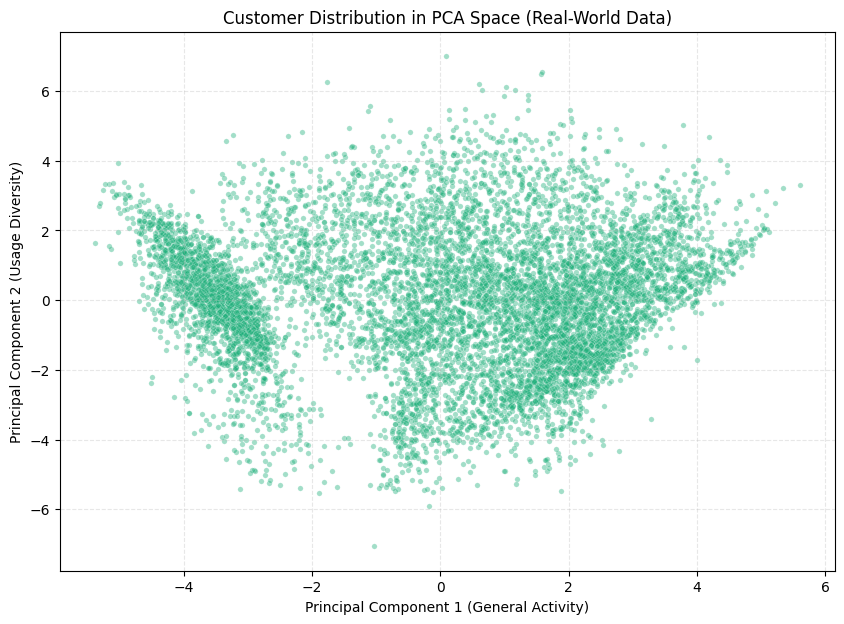

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    data=df_pca, 
    alpha=0.4, 
    s=15,
    color="#17ad76"
)

plt.title('Customer Distribution in PCA Space (Real-World Data)')
plt.xlabel('Principal Component 1 (General Activity)')
plt.ylabel('Principal Component 2 (Usage Diversity)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [17]:
save_dataframe(df_pca, 'processed_pca_data.csv', index=False)
print('Exported!')

Exported!


,PC1 Loading,PC2 Loading
PURCHASES_TRX,0.372675,0.171151
PURCHASES_FREQUENCY,0.368202,0.115452
PURCHASES,0.362804,0.127481
INSTALLMENTS_PURCHASES,0.324452,0.074835
PURCHASES_INSTALLMENTS_FREQUENCY,0.313545,0.068105
CASH_ADVANCE,-0.296882,0.252201
CASH_ADVANCE_TRX,-0.277187,0.279835
CASH_ADVANCE_FREQUENCY,-0.260259,0.271396
ONEOFF_PURCHASES_FREQUENCY,0.220029,0.226226
ONEOFF_PURCHASES,0.208780,0.224349


,PC1 Loading,PC2 Loading
BALANCE,-0.121569,0.435467
MINIMUM_PAYMENTS,-0.101323,0.364122
BALANCE_FREQUENCY,0.018127,0.325520
PAYMENTS,0.053489,0.317145
CASH_ADVANCE_TRX,-0.277187,0.279835
CASH_ADVANCE_FREQUENCY,-0.260259,0.271396
CASH_ADVANCE,-0.296882,0.252201
CREDIT_LIMIT,0.047051,0.249872
ONEOFF_PURCHASES_FREQUENCY,0.220029,0.226226
ONEOFF_PURCHASES,0.208780,0.224349


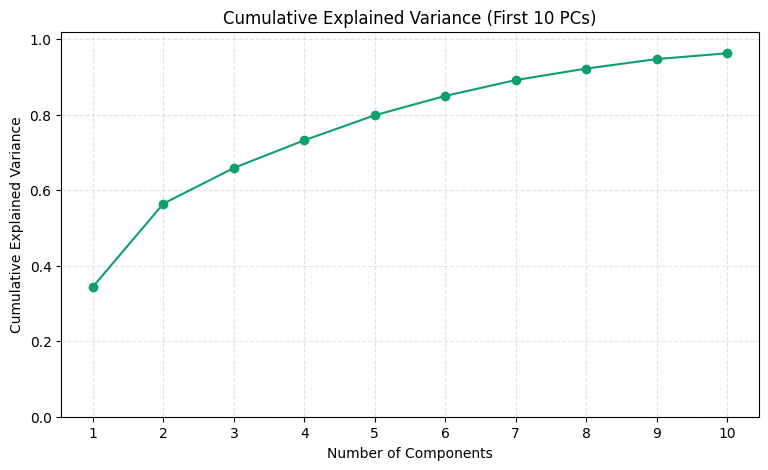

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_log.columns,
    columns=['PC1 Loading', 'PC2 Loading']
 )

display(loadings.sort_values('PC1 Loading', key=np.abs, ascending=False).head(10))
display(loadings.sort_values('PC2 Loading', key=np.abs, ascending=False).head(10))

plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, 11),
    variance_table['Cumulative Explained Variance'].iloc[:10],
    marker='o',
    color='#0e9f6e'
 )
plt.xticks(np.arange(1, 11))
plt.ylim(0, 1.02)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance (First 10 PCs)')
plt.grid(True, linestyle='--', alpha=0.35)
plt.show()

In this notebook, we transformed noisy real-world customer data into a geometry suitable for clustering. The pipeline was:
1. Robust preprocessing (median imputation + log transform)
2. Standardization to zero-mean, unit-variance space
3. PCA projection into a lower-dimensional latent representation

From a linear-algebra perspective, the core map was:
$$Y = ZV_k, \quad \Sigma = \frac{1}{n-1}Z^T Z, \quad \Sigma v_i = \lambda_i v_i$$
where $Z$ is standardized data, $V_k$ contains the first $k$ principal directions, and $Y$ is the embedded representation used for geometric analysis.

The practical outcome is a stable 2D representation that preserves the strongest variance structure and is ready for cluster discovery.

In Notebook 3, we use this representation to compare clustering alternatives quantitatively (inertia, silhouette, and separation behavior) and select a defensible segmentation model.